# Problem 1 – CTG: Zbieżność rozkładu średniej do rozkładu normalnego

**SAD 2026L · Projekt 2**

Celem jest zbadanie zbieżności rozkładu $\bar{X}_n$ do rozkładu normalnego (Centralne Twierdzenie Graniczne) przy użyciu trzech testów zgodności:

1. Test Kołmogorowa–Smirnowa (KS)
2. Test Shapiro–Wilka (SW)
3. Test D'Agostino

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

from pathlib import Path

from scipy import stats
from scipy.stats import kstest, shapiro, normaltest, norm, expon, skew, kurtosis, skewtest, kurtosistest

warnings.filterwarnings('ignore')

In [2]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

In [3]:
DIST_NAME = "Exponential(λ=1)"
DIST_SAMPLE = lambda size: rng.exponential(scale=1.0, size=size)

ALPHA = 0.05                                                # significance level (used for tests and power)
K = 60                                                      # number of sample means (K ≈ "several dozen")
N_VALUES = [1, 2, 5, 10, 20, 50, 100]                       # number of variables being averaged
N_POWER = [1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50, 100]       # finer grid for power curve
MONTE_CARLO_REPS = 3000                                     # repetitions for power analysis (Section C)
MONTE_CARLO_REPS_VIZ = 1000                                 # repetitions for per-test deep-dive plots

print(f"Distribution: {DIST_NAME}")
print(f"K (sample means per run): {K}")
print(f"Significance level α: {ALPHA}")
print(f"Monte Carlo repetitions: {MONTE_CARLO_REPS}")

Distribution: Exponential(λ=1)
K (sample means per run): 60
Significance level α: 0.05
Monte Carlo repetitions: 3000


In [4]:
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

print(f"Images will be saved to: {IMAGES_DIR.resolve()} (exists {IMAGES_DIR.exists()})")

Images will be saved to: /home/dominika/Desktop/26L_sem8_mgr1/SAD/SAD-Project-2/central_limit_theorem/images (exists True)


In [5]:
def generate_means(n: int, K: int) -> np.ndarray:
    data = DIST_SAMPLE((K, n))

    return data.mean(axis=1)

## Wybrany rozkład zmiennej $X$: Wykładniczy(λ=1)

Celowo silnie asymetryczny (prawostronnie skośny, ciężki ogon), co pozwala dobrze zilustrować działanie CTG.

In [6]:
dist = stats.expon(scale=1)

TRUE_MEAN = dist.mean()
TRUE_VAR = dist.var()
TRUE_MEAN_X2 = dist.moment(2)
TRUE_VAR_X2 = dist.moment(4) - dist.moment(2)**2

print(f"Rozkład: {DIST_NAME}")
print(f"Prawdziwa wartość oczekiwana: {TRUE_MEAN:.2f}")
print(f"Prawdziwa wariancja: {TRUE_VAR:.2f}")
print(f"Prawdziwa wartość oczekiwana X^2: {TRUE_MEAN_X2:.2f}")
print(f"Prawdziwa wariancja X^2: {TRUE_VAR_X2:.2f}")

Rozkład: Exponential(λ=1)
Prawdziwa wartość oczekiwana: 1.00
Prawdziwa wariancja: 1.00
Prawdziwa wartość oczekiwana X^2: 2.00
Prawdziwa wariancja X^2: 20.00


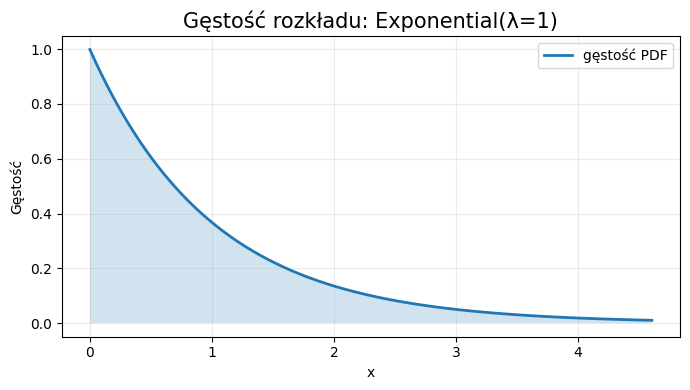

In [7]:
x = np.linspace(dist.ppf(0.001), dist.ppf(0.99), 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, dist.pdf(x), lw=2, label='gęstość PDF')
ax.fill_between(x, dist.pdf(x), alpha=0.2)
ax.set_title(f"Gęstość rozkładu: {DIST_NAME}", fontsize=15)
ax.set_xlabel('x')
ax.set_ylabel('Gęstość')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / f"distribution_density.pdf")
plt.show()

## Wizualna ilustracja zbieżności CTG

Generowanie histogramów i wykresów Q-Q dla różnych wartości n

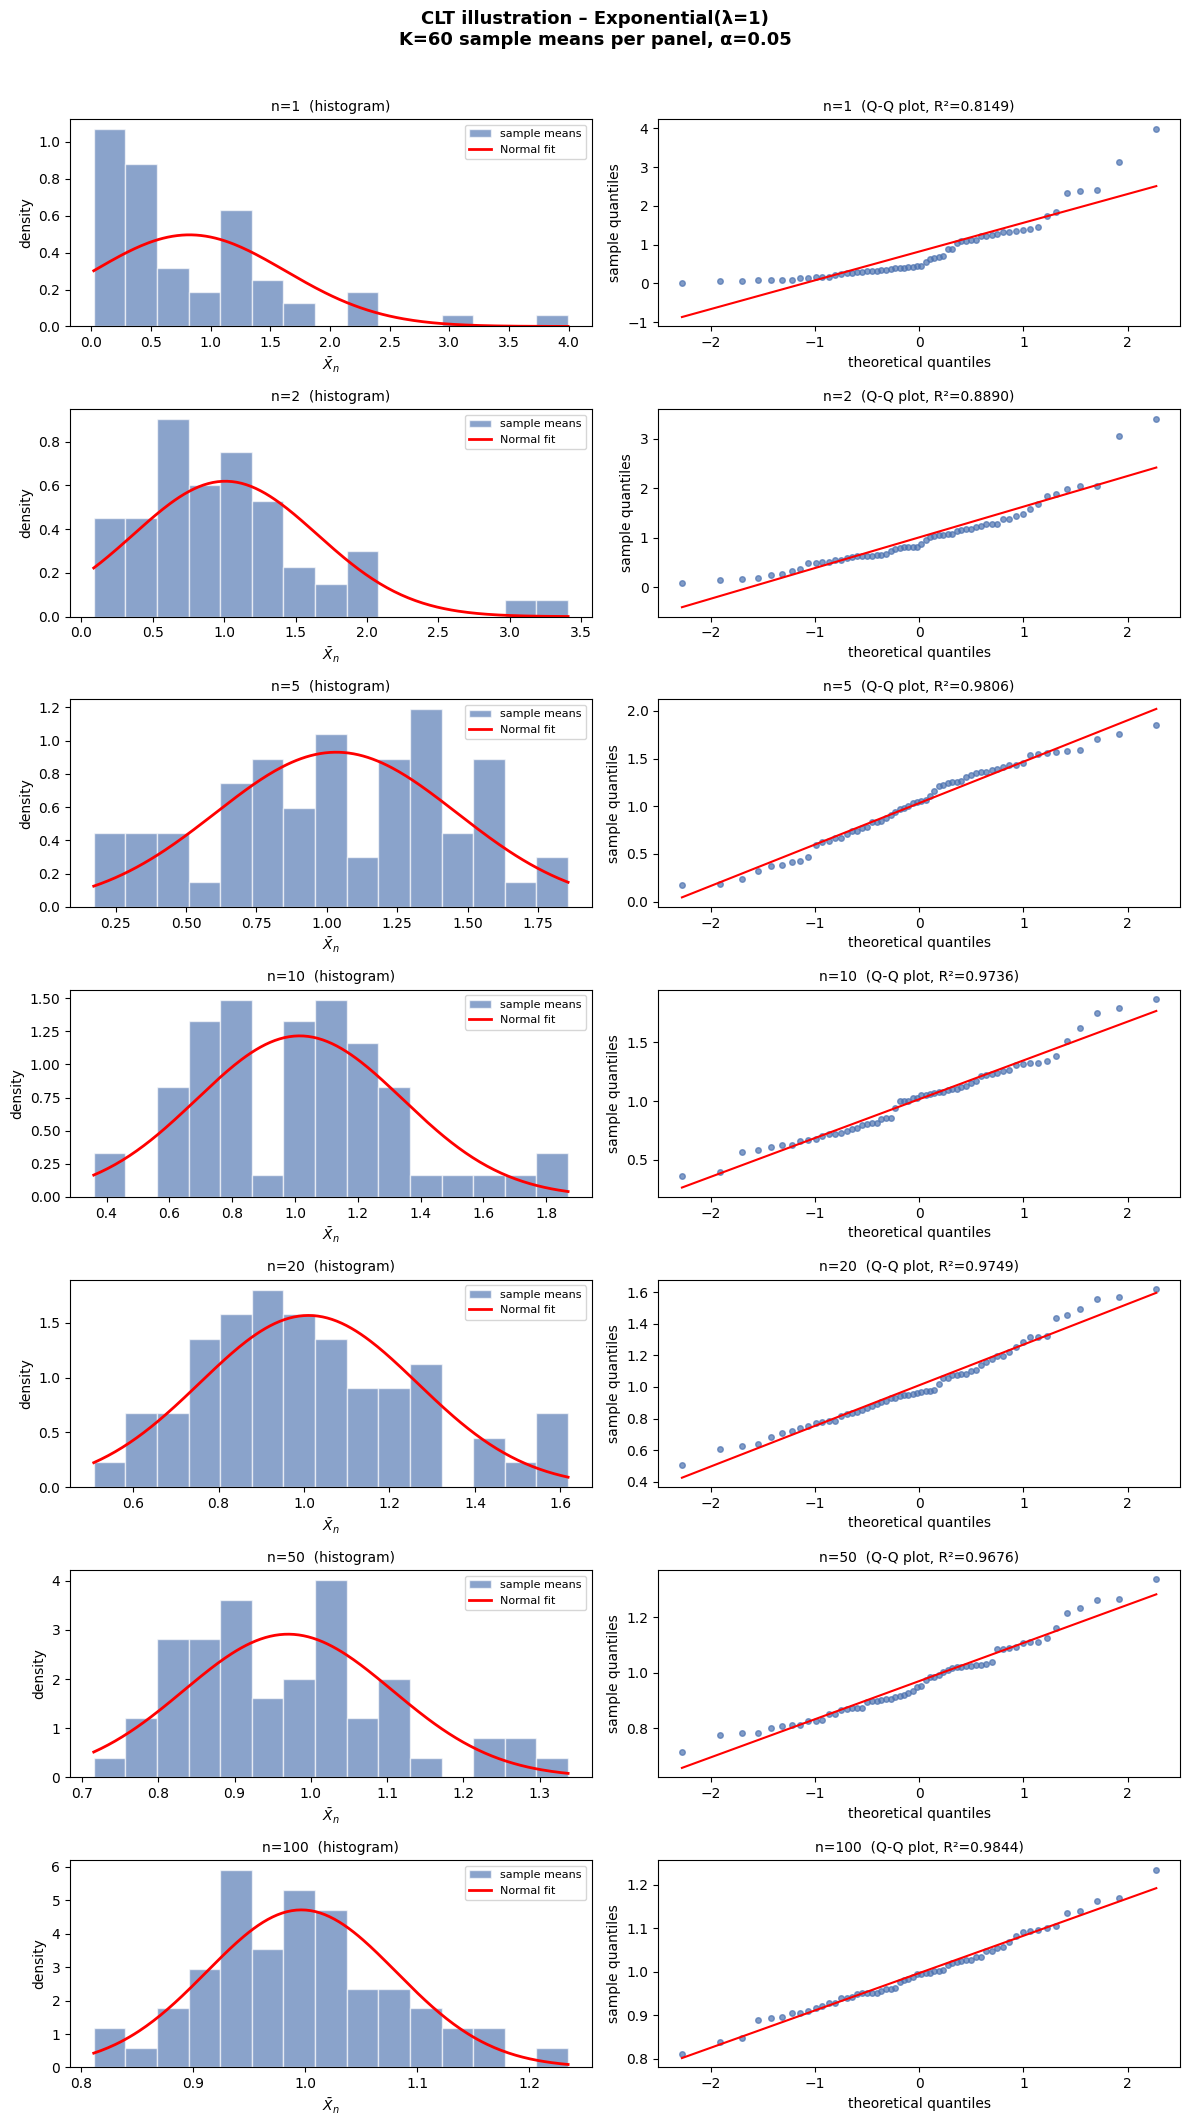

In [8]:
n_plots = len(N_VALUES)
fig, axes = plt.subplots(n_plots, 2, figsize=(12, 3 * n_plots))
fig.suptitle(
    f"CLT illustration – {DIST_NAME}\n"
    f"K={K} sample means per panel, α={ALPHA}",
    fontsize=13, fontweight="bold", y=1.01
)

for row, n in enumerate(N_VALUES):
    means = generate_means(n, K)
    mu_hat  = means.mean()
    sig_hat = means.std(ddof=1)

    # -- Histogram --
    ax_hist = axes[row, 0]
    ax_hist.hist(means, bins=15, density=True, color="#4C72B0", alpha=0.65, edgecolor="white", label="sample means")
    x_grid = np.linspace(means.min(), means.max(), 200)
    ax_hist.plot(x_grid, norm.pdf(x_grid, mu_hat, sig_hat), "r-", lw=2, label="Normal fit")
    ax_hist.set_title(f"n={n}  (histogram)", fontsize=10)
    ax_hist.set_xlabel(r"$\bar{X}_n$"); ax_hist.set_ylabel("density")
    ax_hist.legend(fontsize=8)

    # -- Q-Q plot --
    ax_qq = axes[row, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(means, dist="norm")
    ax_qq.plot(osm, osr, "o", ms=4, color="#4C72B0", alpha=0.7)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, "r-", lw=1.5)
    ax_qq.set_title(f"n={n}  (Q-Q plot, R²={r**2:.4f})", fontsize=10)
    ax_qq.set_xlabel("theoretical quantiles"); ax_qq.set_ylabel("sample quantiles")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "histograms_qq.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Test Kołmogorowa-Smirnowa

In [9]:
def run_ks_test(data: np.ndarray) -> tuple[float, float]:
    mu, sigma = data.mean(), data.std(ddof=1)
    stat, p = kstest(data, "norm", args=(mu, sigma))

    return float(stat), float(p)

### ECDF vs dopasowana CDF normalna

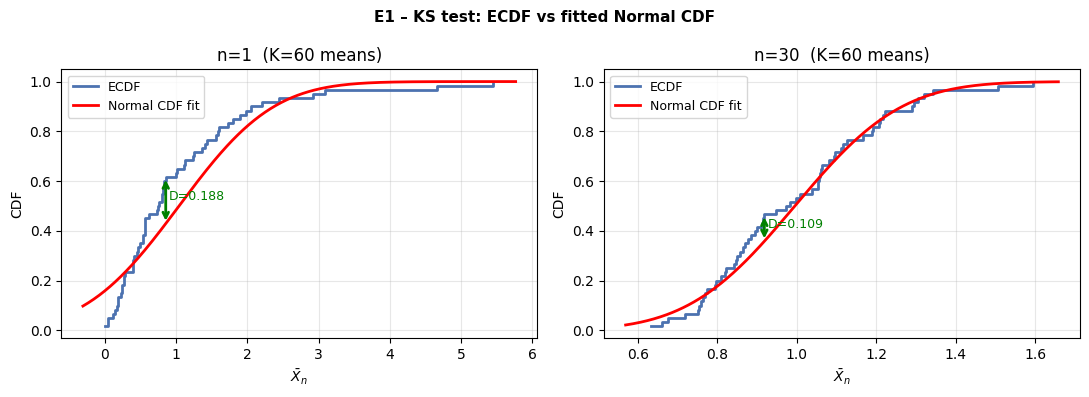

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("E1 – KS test: ECDF vs fitted Normal CDF", fontsize=11, fontweight="bold")

for ax, n in zip(axes, [1, 30]):
    means = generate_means(n, K)
    mu_hat, sig_hat = means.mean(), means.std(ddof=1)

    sorted_means = np.sort(means)
    ecdf = np.arange(1, K + 1) / K

    x_fine = np.linspace(sorted_means[0] - 0.3 * sig_hat, sorted_means[-1] + 0.3 * sig_hat, 400)
    cdf_fit = norm.cdf(x_fine, mu_hat, sig_hat)

    d_stat, _ = run_ks_test(means)

    ax.step(sorted_means, ecdf, where="post", color="#4C72B0", lw=2, label="ECDF")
    ax.plot(x_fine, cdf_fit, "r-", lw=2, label="Normal CDF fit")

    cdf_at_data = norm.cdf(sorted_means, mu_hat, sig_hat)
    gap_idx = np.argmax(np.abs(ecdf - cdf_at_data))
    x_gap = sorted_means[gap_idx]

    y_lo  = min(ecdf[gap_idx], cdf_at_data[gap_idx])
    y_hi  = max(ecdf[gap_idx], cdf_at_data[gap_idx])

    ax.annotate("", xy=(x_gap, y_hi), xytext=(x_gap, y_lo), arrowprops=dict(arrowstyle="<->", color="green", lw=2))
    ax.text(x_gap + 0.04 * sig_hat, (y_lo + y_hi) / 2, f"D={d_stat:.3f}", color="green", fontsize=9)

    ax.set_title(f"n={n}  (K={K} means)")
    ax.set_xlabel(r"$\bar{X}_n$"); ax.set_ylabel("CDF")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "ks_ecdf.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład statystyki D

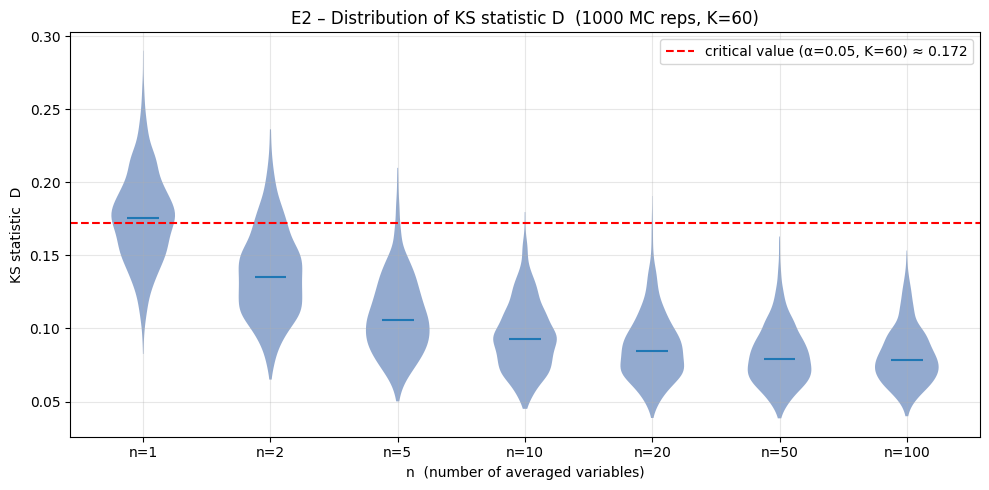

In [11]:
D_collections = []

for n in N_VALUES:
    ds = [run_ks_test(generate_means(n, K))[0] for _ in range(MONTE_CARLO_REPS_VIZ)]
    D_collections.append(ds)

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(D_collections, positions=range(len(N_VALUES)), showmedians=True, showextrema=False)

for pc in parts["bodies"]:
    pc.set_facecolor("#4C72B0"); pc.set_alpha(0.6)

ks_crit = stats.ksone.ppf(1 - ALPHA / 2, K)

ax.axhline(ks_crit, color="red", ls="--", lw=1.5, label=f"critical value (α={ALPHA}, K={K}) ≈ {ks_crit:.3f}")
ax.set_xticks(range(len(N_VALUES)))
ax.set_xticklabels([f"n={n}" for n in N_VALUES])
ax.set_xlabel("n  (number of averaged variables)")
ax.set_ylabel("KS statistic  D")
ax.set_title(f"E2 – Distribution of KS statistic D  ({MONTE_CARLO_REPS_VIZ} MC reps, K={K})")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "ks_stat_violin.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład p-wartości

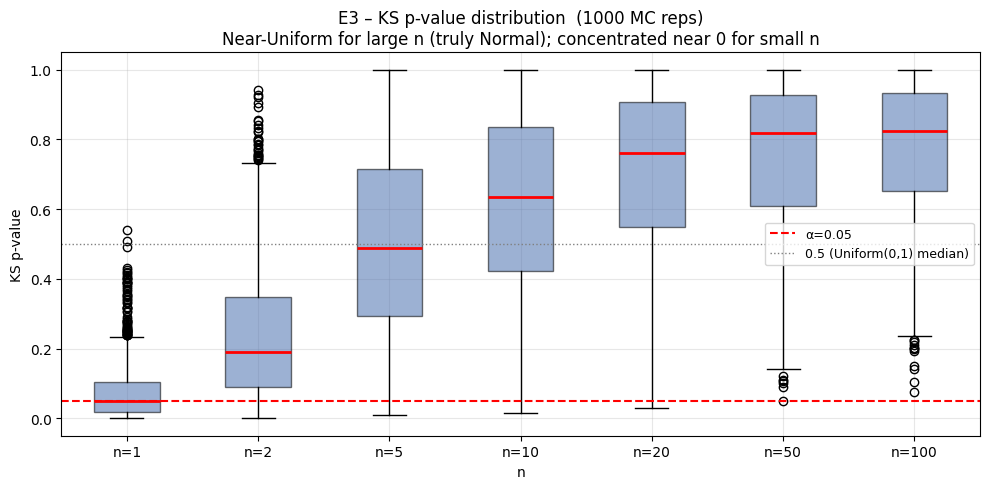

In [12]:
P_collections = []

for n in N_VALUES:
    ps = [run_ks_test(generate_means(n, K))[1] for _ in range(MONTE_CARLO_REPS_VIZ)]
    P_collections.append(ps)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(P_collections, labels=[f"n={n}" for n in N_VALUES], patch_artist=True, medianprops={"color": "red", "lw": 2})

for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0"); patch.set_alpha(0.55)

ax.axhline(ALPHA, color="red", ls="--", lw=1.5, label=f"α={ALPHA}")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="0.5 (Uniform(0,1) median)")
ax.set_xlabel("n"); ax.set_ylabel("KS p-value")
ax.set_title(f"E3 – KS p-value distribution  ({MONTE_CARLO_REPS_VIZ} MC reps)\n"
             f"Near-Uniform for large n (truly Normal); concentrated near 0 for small n")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "ks_pvalue_dist.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Test Shapiro-Wilka

In [13]:
def run_sw_test(data: np.ndarray) -> tuple[float, float]:
    stat, p = shapiro(data)

    return float(stat), float(p)

### Statystyka W dla pojedynczego losowania

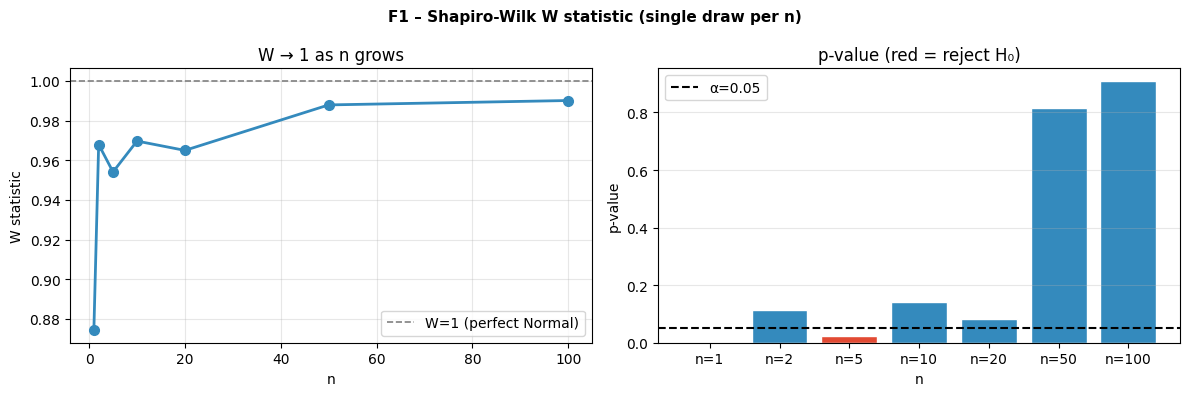

In [14]:
w_vals, p_vals_single = [], []

for n in N_VALUES:
    w, p = run_sw_test(generate_means(n, K))
    w_vals.append(w); p_vals_single.append(p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("F1 – Shapiro-Wilk W statistic (single draw per n)", fontsize=11, fontweight="bold")

ax1.plot(N_VALUES, w_vals, "o-", color="#348ABD", lw=2, ms=7)
ax1.axhline(1.0, color="gray", ls="--", lw=1.2, label="W=1 (perfect Normal)")
ax1.set_xlabel("n"); ax1.set_ylabel("W statistic")
ax1.set_title("W → 1 as n grows")
ax1.legend(); ax1.grid(True, alpha=0.3)

bar_colors = ["#E24A33" if p < ALPHA else "#348ABD" for p in p_vals_single]

ax2.bar([f"n={n}" for n in N_VALUES], p_vals_single, color=bar_colors, edgecolor="white")
ax2.axhline(ALPHA, color="black", ls="--", lw=1.5, label=f"α={ALPHA}")
ax2.set_xlabel("n"); ax2.set_ylabel("p-value")
ax2.set_title("p-value (red = reject H₀)")
ax2.legend(); ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sw_single.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład statystyki W

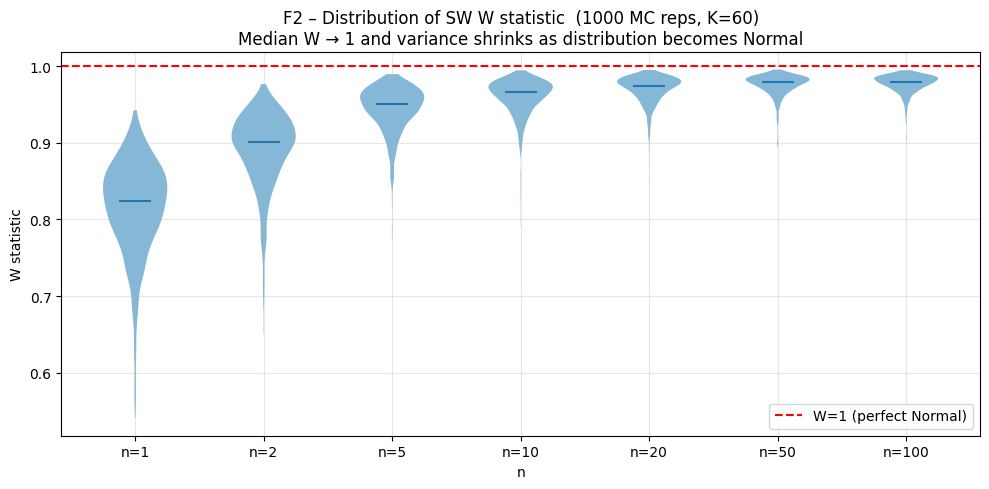

In [15]:
W_collections = []

for n in N_VALUES:
    ws = [run_sw_test(generate_means(n, K))[0] for _ in range(MONTE_CARLO_REPS_VIZ)]
    W_collections.append(ws)

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(W_collections, positions=range(len(N_VALUES)), showmedians=True, showextrema=False)

for pc in parts["bodies"]:
    pc.set_facecolor("#348ABD"); pc.set_alpha(0.6)

ax.axhline(1.0, color="red", ls="--", lw=1.5, label="W=1 (perfect Normal)")
ax.set_xticks(range(len(N_VALUES)))
ax.set_xticklabels([f"n={n}" for n in N_VALUES])
ax.set_xlabel("n"); ax.set_ylabel("W statistic")
ax.set_title(f"F2 – Distribution of SW W statistic  ({MONTE_CARLO_REPS_VIZ} MC reps, K={K})\n"
             "Median W → 1 and variance shrinks as distribution becomes Normal")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sw_stat_violin.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład p-wartości

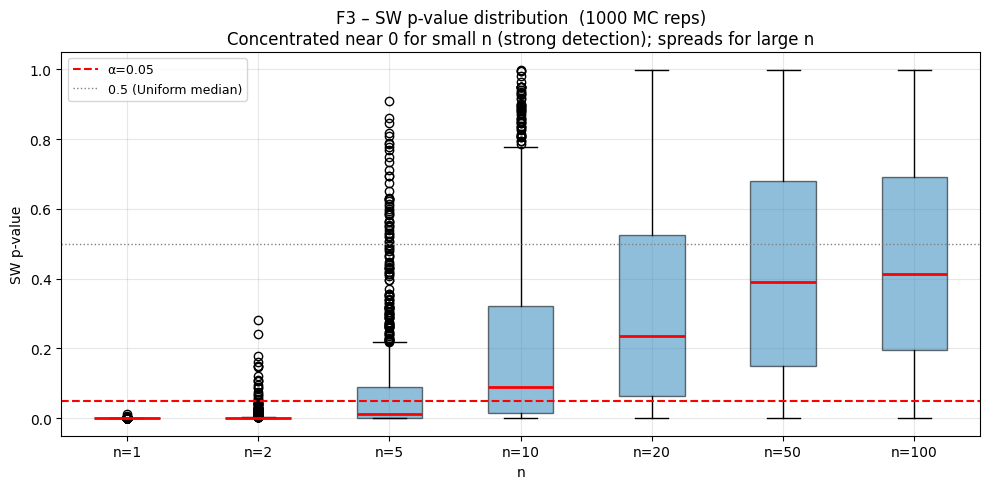

In [16]:
P_collections = []

for n in N_VALUES:
    ps = [run_sw_test(generate_means(n, K))[1] for _ in range(MONTE_CARLO_REPS_VIZ)]
    P_collections.append(ps)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(P_collections, labels=[f"n={n}" for n in N_VALUES], patch_artist=True, medianprops={"color": "red", "lw": 2})

for patch in bp["boxes"]:
    patch.set_facecolor("#348ABD"); patch.set_alpha(0.55)

ax.axhline(ALPHA, color="red", ls="--", lw=1.5, label=f"α={ALPHA}")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="0.5 (Uniform median)")
ax.set_xlabel("n"); ax.set_ylabel("SW p-value")
ax.set_title(f"F3 – SW p-value distribution  ({MONTE_CARLO_REPS_VIZ} MC reps)\n"
             "Concentrated near 0 for small n (strong detection); spreads for large n")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "sw_pvalue_dist.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Test D'Agostino

In [17]:
def run_dagostino_test(data: np.ndarray) -> tuple[float, float]:
    stat, p = normaltest(data)

    return float(stat), float(p)

### Wykres rozrzutu (skośność, kurtoza)

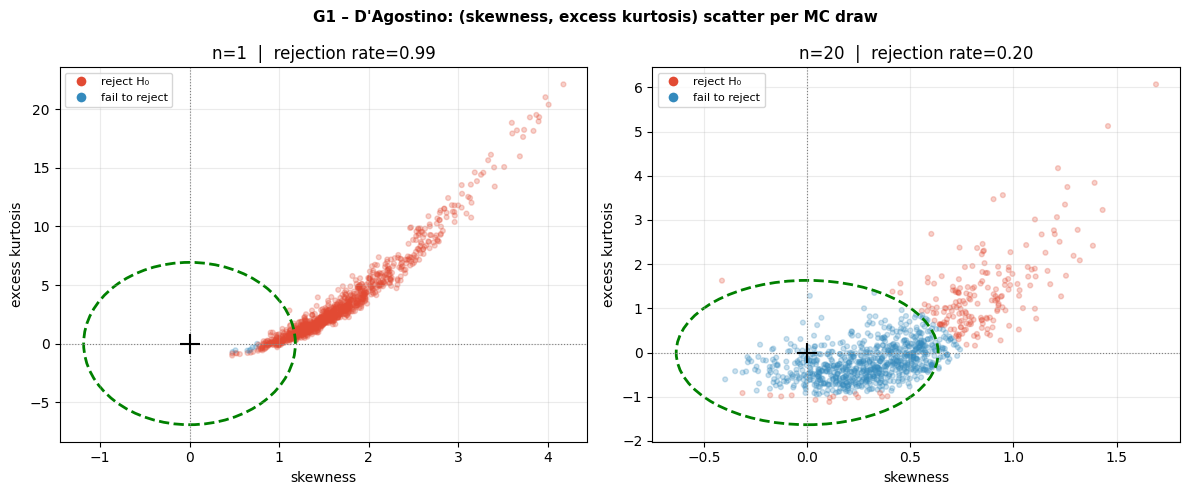

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("G1 – D'Agostino: (skewness, excess kurtosis) scatter per MC draw", fontsize=11, fontweight="bold")

for ax, n in zip(axes, [1, 20]):
    sk_list, ku_list, k2_list = [], [], []

    for _ in range(MONTE_CARLO_REPS_VIZ):
        m = generate_means(n, K)

        sk_list.append(float(skew(m)))
        ku_list.append(float(kurtosis(m, fisher=True)))
        k2_list.append(float(normaltest(m)[0]))

    sk_arr = np.array(sk_list)
    ku_arr = np.array(ku_list)
    k2_arr = np.array(k2_list)

    chi2_crit = stats.chi2.ppf(1 - ALPHA, df=2)
    colors_sc = np.where(k2_arr > chi2_crit, "#E24A33", "#348ABD")

    ax.scatter(sk_arr, ku_arr, c=colors_sc, alpha=0.25, s=12)
    ax.axvline(0, color="gray", lw=0.8, ls=":")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.scatter([0], [0], marker="+", s=200, color="black", zorder=5, label="(0, 0) Normal")

    ell = Ellipse(
        (0, 0), width=4 * np.std(sk_arr), height=4 * np.std(ku_arr),
        angle=0, edgecolor="green", facecolor="none",
        lw=2, ls="--", label="2σ ellipse (empirical)"
    )

    ax.add_patch(ell)

    reject_frac = (k2_arr > chi2_crit).mean()

    ax.set_title(f"n={n}  |  rejection rate={reject_frac:.2f}")
    ax.set_xlabel("skewness"); ax.set_ylabel("excess kurtosis")
    ax.legend(fontsize=8, loc="upper right")

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=lbl)
            for c, lbl in [("#E24A33", "reject H₀"), ("#348ABD", "fail to reject")]
    ]

    ax.legend(handles=handles, fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "da_scatter.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład statystyki K²

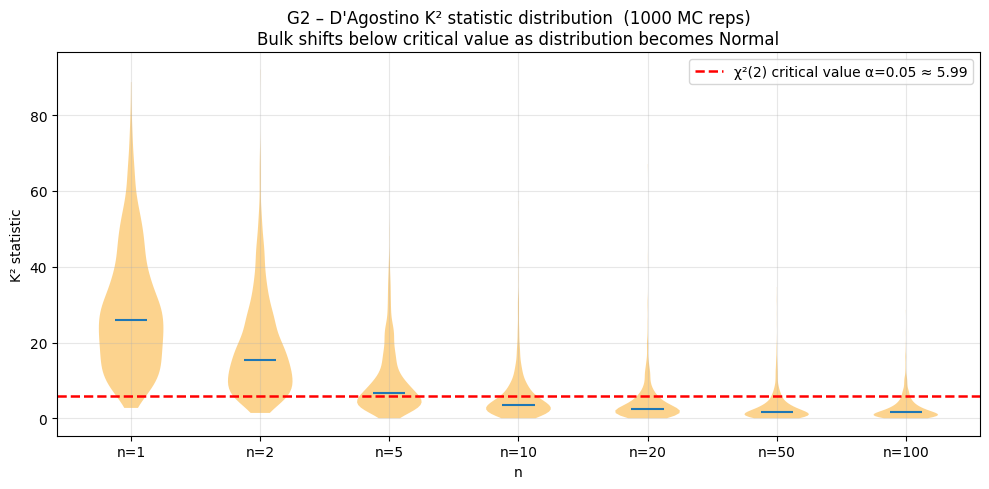

In [19]:
K2_collections = []

for n in N_VALUES:
    k2s = [run_dagostino_test(generate_means(n, K))[0] for _ in range(MONTE_CARLO_REPS_VIZ)]
    K2_collections.append(k2s)

chi2_crit = stats.chi2.ppf(1 - ALPHA, df=2)

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(K2_collections, positions=range(len(N_VALUES)), showmedians=True, showextrema=False)

for pc in parts["bodies"]:
    pc.set_facecolor("#FBC15E"); pc.set_alpha(0.7)

ax.axhline(chi2_crit, color="red", ls="--", lw=1.8,
           label=f"χ²(2) critical value α={ALPHA} ≈ {chi2_crit:.2f}")
ax.set_xticks(range(len(N_VALUES)))
ax.set_xticklabels([f"n={n}" for n in N_VALUES])
ax.set_xlabel("n"); ax.set_ylabel("K² statistic")
ax.set_title(f"G2 – D'Agostino K² statistic distribution  ({MONTE_CARLO_REPS_VIZ} MC reps)\n"
             "Bulk shifts below critical value as distribution becomes Normal")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "da_K2_violin.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Rozkład p-wartości

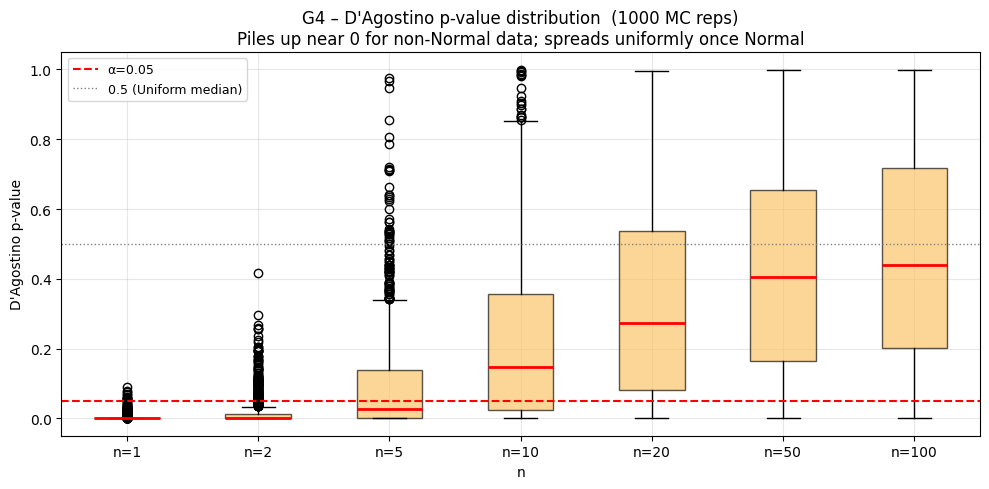

In [20]:
P_collections = []

for n in N_VALUES:
    ps = [run_dagostino_test(generate_means(n, K))[1] for _ in range(MONTE_CARLO_REPS_VIZ)]
    P_collections.append(ps)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(P_collections, labels=[f"n={n}" for n in N_VALUES], patch_artist=True, medianprops={"color": "red", "lw": 2})

for patch in bp["boxes"]:
    patch.set_facecolor("#FBC15E"); patch.set_alpha(0.65)

ax.axhline(ALPHA, color="red", ls="--", lw=1.5, label=f"α={ALPHA}")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="0.5 (Uniform median)")
ax.set_xlabel("n"); ax.set_ylabel("D'Agostino p-value")
ax.set_title(f"G4 – D'Agostino p-value distribution  ({MONTE_CARLO_REPS_VIZ} MC reps)\n"
             "Piles up near 0 for non-Normal data; spreads uniformly once Normal")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "da_pvalue_dist.pdf", dpi=130, bbox_inches="tight")
plt.show()

### Skośność i kurtoza

In [21]:
skew_means  = []
kurt_means  = []
skew_stds   = []
kurt_stds   = []

N_SK = N_POWER

for n in N_SK:
    sk_list, ku_list = [], []

    for _ in range(MONTE_CARLO_REPS):
        m = generate_means(n, K)
        sk_list.append(float(skew(m)))
        ku_list.append(float(kurtosis(m, fisher=True)))  # excess kurtosis

    skew_means.append(np.mean(sk_list))
    skew_stds.append(np.std(sk_list))
    kurt_means.append(np.mean(ku_list))
    kurt_stds.append(np.std(ku_list))

    print(f"  n={n:4d}  skewness={skew_means[-1]:+.4f} ±{skew_stds[-1]:.4f}"
          f"   excess kurtosis={kurt_means[-1]:+.4f} ±{kurt_stds[-1]:.4f}")

  n=   1  skewness=+1.6798 ±0.5879   excess kurtosis=+3.3960 ±3.4975
  n=   2  skewness=+1.2078 ±0.4659   excess kurtosis=+1.7131 ±2.2260
  n=   3  skewness=+1.0075 ±0.4354   excess kurtosis=+1.2036 ±1.9037
  n=   4  skewness=+0.8676 ±0.4071   excess kurtosis=+0.8513 ±1.6459
  n=   5  skewness=+0.7770 ±0.3825   excess kurtosis=+0.6651 ±1.4383
  n=   8  skewness=+0.6263 ±0.3534   excess kurtosis=+0.3968 ±1.1334
  n=  10  skewness=+0.5675 ±0.3535   excess kurtosis=+0.3114 ±1.0788
  n=  15  skewness=+0.4597 ±0.3365   excess kurtosis=+0.1852 ±0.9561
  n=  20  skewness=+0.3901 ±0.3239   excess kurtosis=+0.0942 ±0.8390
  n=  30  skewness=+0.3180 ±0.3083   excess kurtosis=+0.0160 ±0.7042
  n=  50  skewness=+0.2495 ±0.3105   excess kurtosis=-0.0198 ±0.6866
  n= 100  skewness=+0.1779 ±0.3064   excess kurtosis=-0.0498 ±0.6387


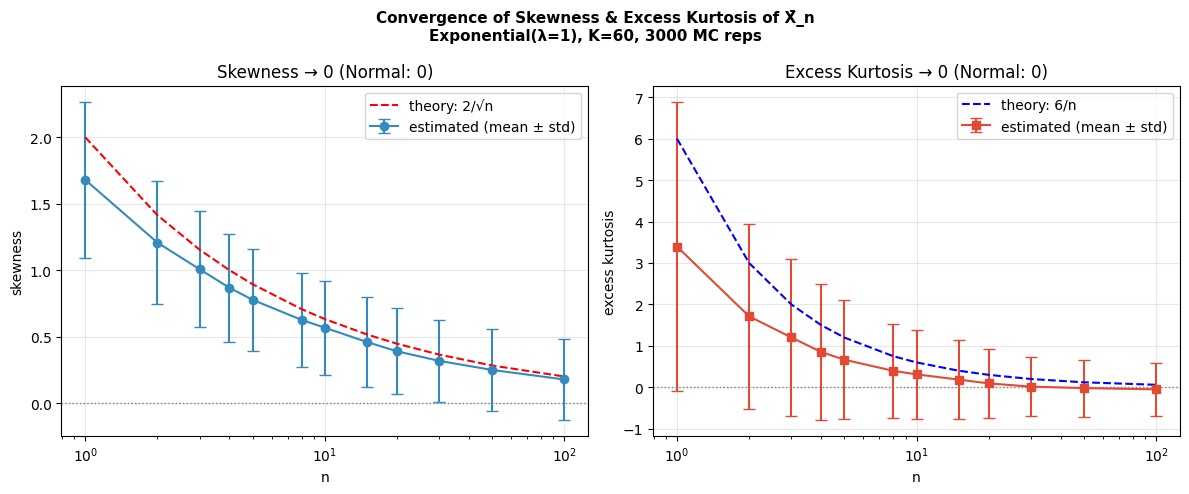

In [22]:
skew_means = np.array(skew_means)
kurt_means = np.array(kurt_means)
skew_stds  = np.array(skew_stds)
kurt_stds  = np.array(kurt_stds)

n_arr = np.array(N_SK, dtype=float)

skew_theory = 2.0 / np.sqrt(n_arr)
kurt_theory = 6.0 / n_arr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Convergence of Skewness & Excess Kurtosis of X̄_n\n"
    f"{DIST_NAME}, K={K}, {MONTE_CARLO_REPS} MC reps",
    fontsize=11, fontweight="bold"
)

ax1.errorbar(N_SK, skew_means, yerr=skew_stds, fmt="o-",
             color="#348ABD", capsize=4, label="estimated (mean ± std)")
ax1.plot(N_SK, skew_theory, "r--", lw=1.5, label="theory: 2/√n")
ax1.axhline(0, color="gray", lw=1, ls=":")
ax1.set_xscale("log"); ax1.set_xlabel("n"); ax1.set_ylabel("skewness")
ax1.set_title("Skewness → 0 (Normal: 0)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.errorbar(N_SK, kurt_means, yerr=kurt_stds, fmt="s-",
             color="#E24A33", capsize=4, label="estimated (mean ± std)")
ax2.plot(N_SK, kurt_theory, "b--", lw=1.5, label="theory: 6/n")
ax2.axhline(0, color="gray", lw=1, ls=":")
ax2.set_xscale("log"); ax2.set_xlabel("n"); ax2.set_ylabel("excess kurtosis")
ax2.set_title("Excess Kurtosis → 0 (Normal: 0)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "skew_kurt.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Pojedyncze uruchomienie – mapa ciepła p-wartości

In [23]:
tests  = {
    "Kolmogorov-Smirnov": run_ks_test,
    "Shapiro-Wilk": run_sw_test,
    "D'Agostino": run_dagostino_test
}

rows   = []
header = f"{'n':>6}  {'KS stat':>9} {'KS p':>9}  " \
         f"{'SW stat':>9} {'SW p':>9}  " \
         f"{'DA stat':>9} {'DA p':>9}"

print(header)
print("-" * len(header))

pval_matrix = np.zeros((len(N_VALUES), 3))

for i, n in enumerate(N_VALUES):
    means = generate_means(n, K)
    results = [fn(means) for fn in tests.values()]
    stats_vals = [r[0] for r in results]
    p_vals = [r[1] for r in results]
    pval_matrix[i] = p_vals

    reject_markers = ["*" if p < ALPHA else " " for p in p_vals]
    line = f"{n:>6}  " + "  ".join(
        f"{s:>9.4f} {p:>9.4f}{m}" for s, p, m in
        zip(stats_vals, p_vals, reject_markers)
    )

    print(line)

print(f"\n  (* = reject H₀ at α={ALPHA}, i.e. significant non-normality)")

     n    KS stat      KS p    SW stat      SW p    DA stat      DA p
---------------------------------------------------------------------
     1     0.1566    0.0945      0.8209    0.0000*    34.5824    0.0000*
     2     0.1480    0.1302      0.8857    0.0000*    22.2019    0.0000*
     5     0.0873    0.7179      0.9787    0.3748      1.3057    0.5206 
    10     0.1001    0.5503      0.9654    0.0869      3.0902    0.2133 
    20     0.0562    0.9859      0.9882    0.8299      0.0523    0.9742 
    50     0.0828    0.7746      0.9621    0.0594      3.1864    0.2033 
   100     0.0679    0.9276      0.9765    0.3004      2.0150    0.3651 

  (* = reject H₀ at α=0.05, i.e. significant non-normality)


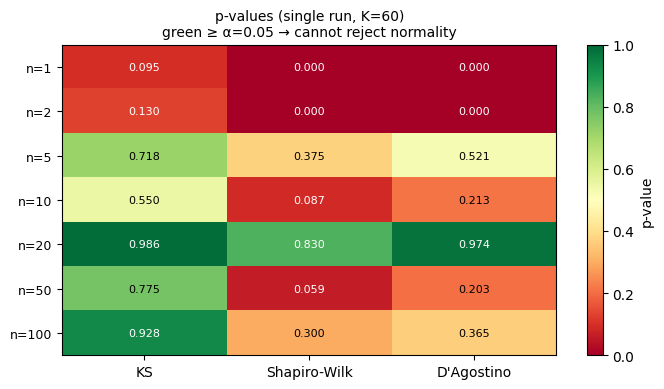

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pval_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, origin="upper")

ax.set_xticks(range(3))
ax.set_xticklabels(["KS", "Shapiro-Wilk", "D'Agostino"], fontsize=10)
ax.set_yticks(range(len(N_VALUES)))
ax.set_yticklabels([f"n={n}" for n in N_VALUES], fontsize=9)
ax.set_title(f"p-values (single run, K={K})\n"
             f"green ≥ α={ALPHA} → cannot reject normality", fontsize=10)

for i in range(len(N_VALUES)):
    for j in range(3):
        ax.text(
            j, i, f"{pval_matrix[i,j]:.3f}",
            ha="center", va="center", fontsize=8,
            color="black" if 0.2 < pval_matrix[i,j] < 0.8 else "white"
        )

plt.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "pvalue_heatmap.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Analiza mocy testów za pomocą symulacji Monte Carlo

In [25]:
def estimate_power(n: int, K: int, alpha: float, n_reps: int) -> dict[str, float]:
    reject_ks = reject_sw = reject_da = 0

    for _ in range(n_reps):
        means = generate_means(n, K)

        _, p_ks = run_ks_test(means)
        _, p_sw = run_sw_test(means)
        _, p_da = run_dagostino_test(means)

        if p_ks < alpha: reject_ks += 1
        if p_sw < alpha: reject_sw += 1
        if p_da < alpha: reject_da += 1

    return {
        "KS": reject_ks / n_reps,
        "Shapiro-Wilk": reject_sw / n_reps,
        "D'Agostino": reject_da / n_reps,
    }

In [26]:
print(f"n values: {N_POWER}")

power = {"KS": [], "Shapiro-Wilk": [], "D'Agostino": []}

for n in N_POWER:
    p_dict = estimate_power(n, K, ALPHA, MONTE_CARLO_REPS)

    for key in power:
        power[key].append(p_dict[key])

    print(f"  n={n:4d}  KS={p_dict['KS']:.3f}  "
          f"SW={p_dict['Shapiro-Wilk']:.3f}  DA={p_dict['D\'Agostino']:.3f}")

n values: [1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50, 100]
  n=   1  KS=0.529  SW=1.000  DA=0.991
  n=   2  KS=0.129  SW=0.984  DA=0.880
  n=   3  KS=0.044  SW=0.892  DA=0.742
  n=   4  KS=0.028  SW=0.788  DA=0.632
  n=   5  KS=0.017  SW=0.679  DA=0.555
  n=   8  KS=0.005  SW=0.468  DA=0.392
  n=  10  KS=0.004  SW=0.381  DA=0.315
  n=  15  KS=0.004  SW=0.270  DA=0.236
  n=  20  KS=0.001  SW=0.222  DA=0.214
  n=  30  KS=0.002  SW=0.160  DA=0.157
  n=  50  KS=0.001  SW=0.118  DA=0.121
  n= 100  KS=0.000  SW=0.082  DA=0.087


In [27]:
print("\n  Power summary table:")

dagostino = "D'Agostino"
header = f"  {'n':>6}  {'KS':>8}  {'Shapiro-Wilk':>14}  {dagostino:>12}"

print(header)
print("  " + "-" * (len(header) - 2))

for idx, n in enumerate(N_POWER):
    print(f"  {n:>6}  {power['KS'][idx]:>8.3f}  "
          f"{power['Shapiro-Wilk'][idx]:>14.3f}  "
          f"{power[dagostino][idx]:>12.3f}")


  Power summary table:
       n        KS    Shapiro-Wilk    D'Agostino
  ----------------------------------------------
       1     0.529           1.000         0.991
       2     0.129           0.984         0.880
       3     0.044           0.892         0.742
       4     0.028           0.788         0.632
       5     0.017           0.679         0.555
       8     0.005           0.468         0.392
      10     0.004           0.381         0.315
      15     0.004           0.270         0.236
      20     0.001           0.222         0.214
      30     0.002           0.160         0.157
      50     0.001           0.118         0.121
     100     0.000           0.082         0.087


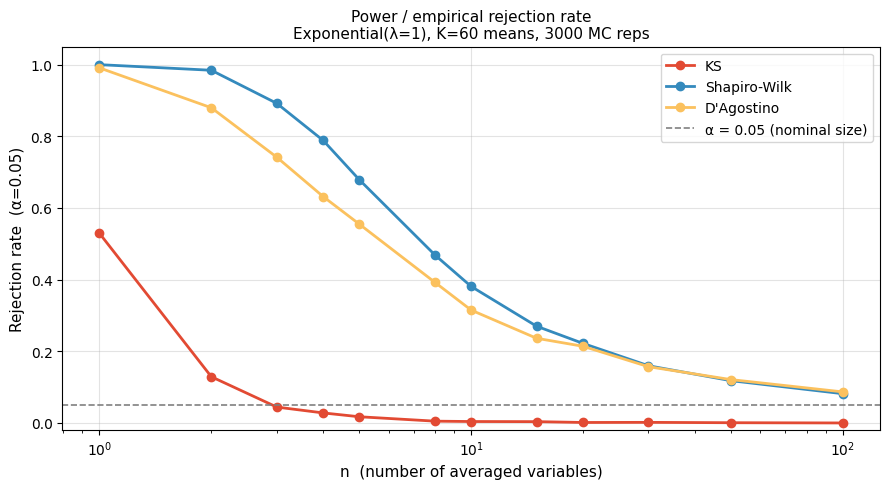

In [28]:
colors = {"KS": "#E24A33", "Shapiro-Wilk": "#348ABD", "D'Agostino": "#FBC15E"}
fig, ax = plt.subplots(figsize=(9, 5))

for test_name, pows in power.items():
    ax.plot(N_POWER, pows, marker="o", lw=2, color=colors[test_name], label=test_name)

ax.axhline(ALPHA, color="gray", lw=1.2, ls="--", label=f"α = {ALPHA} (nominal size)")
ax.set_xlabel("n  (number of averaged variables)", fontsize=11)
ax.set_ylabel(f"Rejection rate  (α={ALPHA})", fontsize=11)
ax.set_title(
    f"Power / empirical rejection rate\n"
    f"{DIST_NAME}, K={K} means, {MONTE_CARLO_REPS} MC reps",
    fontsize=11
)
ax.set_ylim(-0.02, 1.05)
ax.set_xscale("log")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "power_curves.pdf", dpi=130, bbox_inches="tight")
plt.show()